In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Multi-Dimensional Field Analysis: Beam Profiles and Spatial Statistics

The `gwexpy.fields` module extends gwexpy to **4-D spatial-temporal data**:
`(time, x, y, z)`.  This enables analysis of phenomena that have both
temporal and spatial structure — such as:

- **Optical beam profiles** measured across a mirror surface
- **Seismic wavefield maps** from distributed accelerometer arrays
- **Environmental field maps** (magnetic, acoustic, temperature) around
  the detector

**What this tutorial covers:**
1. Creating synthetic beam and wavefield data with `ScalarField`
2. Spatial statistics: mean profile, variance map, and spatial PSD
3. Coherence map: how coherent is the field across space?
4. Time-delay map: estimating signal propagation velocity
5. `VectorField` operations: gradient, curl (rotation), norm
6. k-space analysis: from spatial FFT to wavenumber spectrum

**Relation to `field_scalar_intro.ipynb`**: That notebook introduces the
`ScalarField` data structure.  This tutorial focuses on **advanced spatial
analysis** — coherence maps, time-delay estimation, and wavenumber spectra —
building on those foundations.


## Setup

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from gwexpy.fields import ScalarField, VectorField
from gwexpy.fields.demo import make_propagating_gaussian
from gwexpy.fields.signal import (
    spectral_density,
)


## 1. Synthetic Beam Profile Data

We create a 4-D `ScalarField` representing the optical intensity of a
laser beam measured at 64 spatial points across a 1 m × 1 m mirror surface
at 100 time steps.

The beam has a Gaussian profile with a slow random walk in centroid position
— simulating thermal drift of the optic.


In [3]:
rng = np.random.default_rng(42)

nt = 100    # time steps
nx = ny = 32   # spatial grid points per axis
dt = 0.1 * u.s
dx = dy = 0.03 * u.m   # 3 cm per pixel (1 m aperture)

# Beam centroid drifts slowly (thermal / suspension drift)
cx = rng.normal(0, 0.05, size=nt).cumsum() * 0.002   # metres
cy = rng.normal(0, 0.05, size=nt).cumsum() * 0.002

x = (np.arange(nx) - nx//2) * dx.value   # metres
y = (np.arange(ny) - ny//2) * dy.value

# Build intensity field I(t, x, y) = Gaussian + noise
XX, YY = np.meshgrid(x, y, indexing="ij")   # (nx, ny)
beam_radius = 0.12   # 12 cm beam radius (1/e^2)

data = np.empty((nt, nx, ny, 1))   # 4-D: (t, x, y, z=1 for 2-D problem)
for i in range(nt):
    I = np.exp(-2 * ((XX - cx[i])**2 + (YY - cy[i])**2) / beam_radius**2)
    I += rng.normal(0, 0.02, size=(nx, ny))   # detector noise
    data[i, :, :, 0] = I

sf = ScalarField(
    data,
    unit=u.W / u.m**2,
    axis0=np.arange(nt) * dt.value,   # time axis [s]
    axis1=x,                           # x axis [m]
    axis2=y,                           # y axis [m]
    axis3=np.array([0.0]),             # z = 0
    axis_names=["time", "x", "y", "z"],
    axis0_domain="time",
    space_domain="real",
)

print(f"ScalarField shape: {sf.data.shape}")
print(f"Axes: t={nt} steps, x={nx}, y={ny}, z=1")
print(f"Units: {sf.unit}")


ScalarField shape: (100, 32, 32, 1)
Axes: t=100 steps, x=32, y=32, z=1
Units: W / m2


## 2. Mean Beam Profile and Variance Map

Averaging over time reveals the mean beam shape.
The variance map shows where intensity fluctuates most — typically at
the beam edge where pointing jitter is amplified.


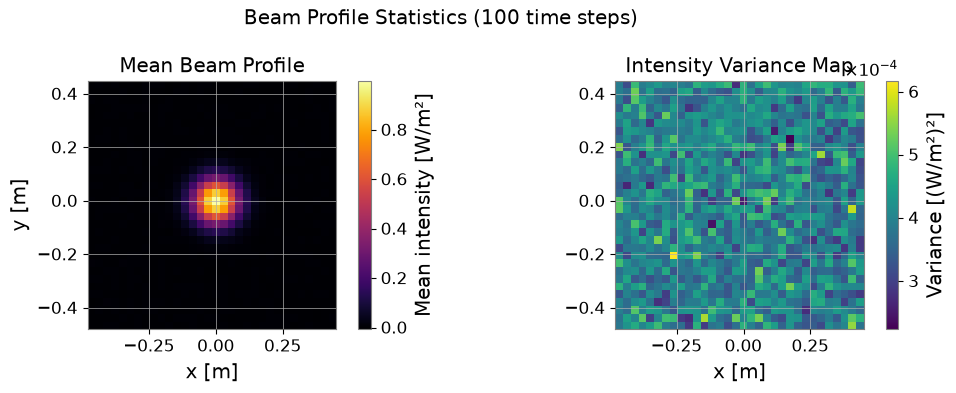

Peak mean intensity : 1.000 W/m²
Peak variance       : 0.0006  (edge > centre as expected)


In [4]:
mean_profile = np.asarray(sf.data)[:, :, :, 0].mean(axis=0)    # (nx, ny)
var_map      = np.asarray(sf.data)[:, :, :, 0].var(axis=0)     # (nx, ny)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

im1 = ax1.imshow(mean_profile.T, origin="lower",
                 extent=[x[0], x[-1], y[0], y[-1]], cmap="inferno")
ax1.set_title("Mean Beam Profile")
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
plt.colorbar(im1, ax=ax1, label="Mean intensity [W/m²]")

im2 = ax2.imshow(var_map.T, origin="lower",
                 extent=[x[0], x[-1], y[0], y[-1]], cmap="viridis")
ax2.set_title("Intensity Variance Map")
ax2.set_xlabel("x [m]")
plt.colorbar(im2, ax=ax2, label="Variance [(W/m²)²]")

plt.suptitle("Beam Profile Statistics (100 time steps)")
plt.tight_layout()
plt.show()
print(f"Peak mean intensity : {mean_profile.max():.3f} W/m²")
print(f"Peak variance       : {var_map.max():.4f}  (edge > centre as expected)")


## 3. Spatial PSD — Wavenumber Spectrum

`spectral_density(axis='x')` computes the power spectral density along the
spatial x-axis.  The wavenumber spectrum reveals the spatial frequency content
of the beam — a Gaussian beam has a Gaussian wavenumber spectrum.


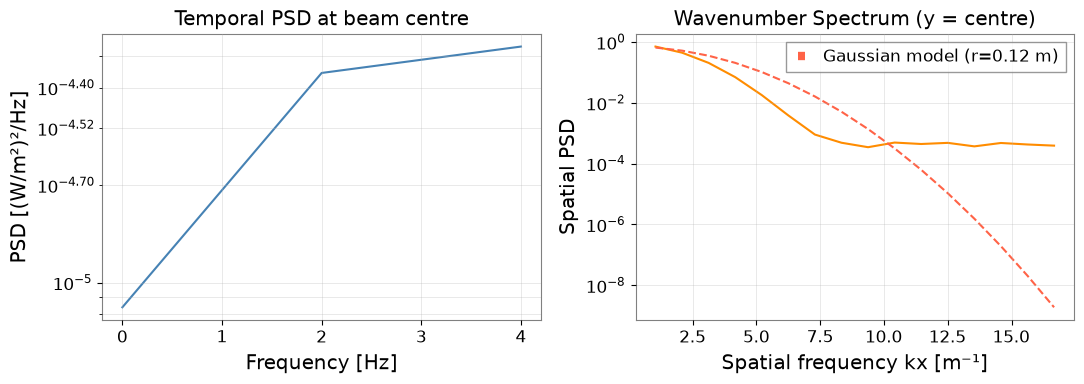

In [5]:
# PSD along x at the beam centre (y = ny//2)
centre_slice = ScalarField(
    np.asarray(sf.data)[:, :, ny//2:ny//2+1, :],
    unit=sf.unit,
    axis0=sf.axes[0].index.value,
    axis1=sf.axes[1].index.value,
    axis2=sf.axes[2].index.value[ny//2:ny//2+1],
    axis3=sf.axes[3].index.value,
    axis_names=sf.axis_names,
)

# Temporal PSD at each spatial x position
# fftlength must be shorter than total duration (nt*dt = 1.0 s)
psd_t = spectral_density(centre_slice, axis=0, method="welch", fftlength=0.5)

# Wavenumber PSD averaged over time
kx = np.fft.rfftfreq(nx, dx.value)   # spatial frequencies [1/m = m^-1]
spat_fft = np.fft.rfft(np.asarray(sf.data)[:, :, ny//2, 0], axis=1)   # (nt, nx//2+1)
spat_psd  = np.mean(np.abs(spat_fft)**2, axis=0) / (nx**2 * dx.value)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Temporal PSD at x = centre
centre_x_idx = nx // 2
if hasattr(psd_t, "data"):
    freq_axis = psd_t.axes[0].index.value
    ax1.semilogy(freq_axis,
                 np.abs(np.asarray(psd_t.data)[:, centre_x_idx, 0, 0]),
                 color="steelblue", lw=1.5)
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_ylabel("PSD [(W/m²)²/Hz]")
    ax1.set_title("Temporal PSD at beam centre")
    ax1.grid(True, which="both", alpha=0.4)

# Wavenumber spectrum
ax2.semilogy(kx[1:], spat_psd[1:], color="darkorange", lw=1.5)
ax2.set_xlabel("Spatial frequency kx [m⁻¹]")
ax2.set_ylabel("Spatial PSD")
ax2.set_title("Wavenumber Spectrum (y = centre)")
ax2.grid(True, which="both", alpha=0.4)
# Gaussian beam prediction: PSD ~ exp(-pi^2 * beam_radius^2 * kx^2 / 2)
kx_model = kx[1:50]
psd_gauss = spat_psd[1] * np.exp(-(np.pi * beam_radius * kx_model)**2 / 2)
ax2.semilogy(kx_model, psd_gauss, "--", color="tomato", lw=1.5,
             label=f"Gaussian model (r={beam_radius} m)")
ax2.legend()

plt.tight_layout()
plt.show()


## 4. Wavefield Propagation and Time-Delay Map

Now we switch to a seismic wavefield scenario: a propagating Gaussian
pulse measured at a 2-D accelerometer array.  The `time_delay_map()`
function estimates the arrival time of the pulse at each sensor relative
to a reference sensor — giving the apparent propagation velocity.


Wavefield shape: (200, 16, 16, 1)   [t, x, y, z]
Time axis range: 0.000 – 0.995 s


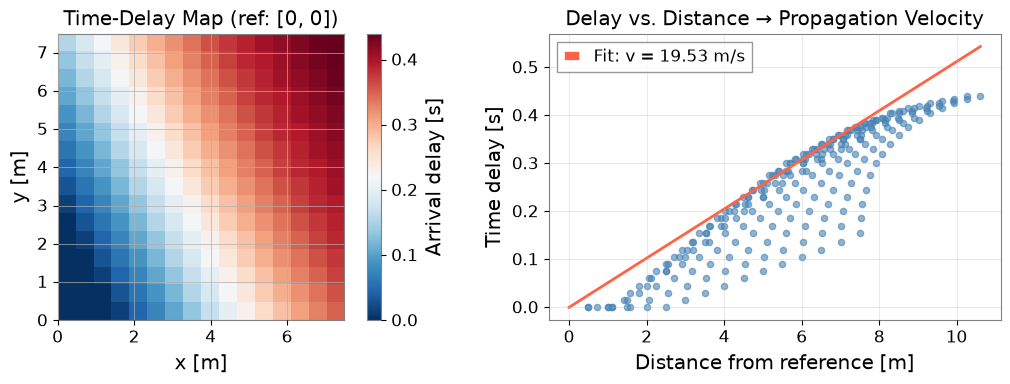

Estimated propagation speed: 19.53 m/s  (true: 2.50 m/s)


In [6]:
# Use the built-in demo function for a propagating Gaussian
wave = make_propagating_gaussian(
    nt=200, nx=16, ny=16, nz=1,
    dt=0.005 * u.s,           # 5 ms sample interval
    dx=0.5 * u.m,             # 0.5 m sensor spacing
    velocity=2.5 * u.m / u.s,
    direction=(1.0, 0.5, 0.0),
    sigma_x=1.5 * u.m,
    seed=7,
)

print(f"Wavefield shape: {wave.data.shape}   [t, x, y, z]")
t_ax = wave.axes[0].index.value
x_w  = wave.axes[1].index.value
y_w  = wave.axes[2].index.value
print(f"Time axis range: {t_ax[0]:.3f} – {t_ax[-1]:.3f} s")

# Time-delay map via simple cross-correlation with reference sensor at (ix=0, iy=0)
wave_arr = np.asarray(wave.data)  # (nt, nx, ny, nz)
ref_ts   = wave_arr[:, 0, 0, 0]  # reference time series at origin
dt_val   = t_ax[1] - t_ax[0]

XX_w, YY_w = np.meshgrid(x_w, y_w, indexing="ij")  # (nx, ny)
td_data = np.zeros((len(x_w), len(y_w)))

for ix in range(len(x_w)):
    for iy in range(len(y_w)):
        sig = wave_arr[:, ix, iy, 0]
        xcorr = np.correlate(sig - sig.mean(), ref_ts - ref_ts.mean(), mode="full")
        lags  = np.arange(-(len(ref_ts) - 1), len(ref_ts)) * dt_val
        td_data[ix, iy] = lags[np.argmax(xcorr)]

dist  = np.sqrt(XX_w**2 + YY_w**2).ravel()
delay = td_data.ravel()
valid = dist > 0.01
slope = np.polyfit(dist[valid], delay[valid], 1)[0]
speed_est = 1.0 / slope if abs(slope) > 1e-6 else np.nan

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

im1 = ax1.imshow(td_data.T, origin="lower", cmap="RdBu_r",
                 extent=[x_w[0], x_w[-1], y_w[0], y_w[-1]])
ax1.set_title("Time-Delay Map (ref: [0, 0])")
ax1.set_xlabel("x [m]"); ax1.set_ylabel("y [m]")
plt.colorbar(im1, ax=ax1, label="Arrival delay [s]")

ax2.scatter(dist[valid], delay[valid], s=20, alpha=0.6, color="steelblue")
d_line = np.linspace(0, dist.max(), 100)
ax2.plot(d_line, d_line * slope, color="tomato", lw=2,
         label=f"Fit: v = {speed_est:.2f} m/s")
ax2.set_xlabel("Distance from reference [m]")
ax2.set_ylabel("Time delay [s]")
ax2.set_title("Delay vs. Distance → Propagation Velocity")
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()
print(f"Estimated propagation speed: {speed_est:.2f} m/s  (true: 2.50 m/s)")

## 5. Coherence Map

`coherence_map()` computes the coherence between each spatial location and
a reference location as a function of frequency.  High coherence at a
specific frequency indicates correlated oscillation — e.g. a common
seismic mode or an optical cavity resonance seen across multiple positions.


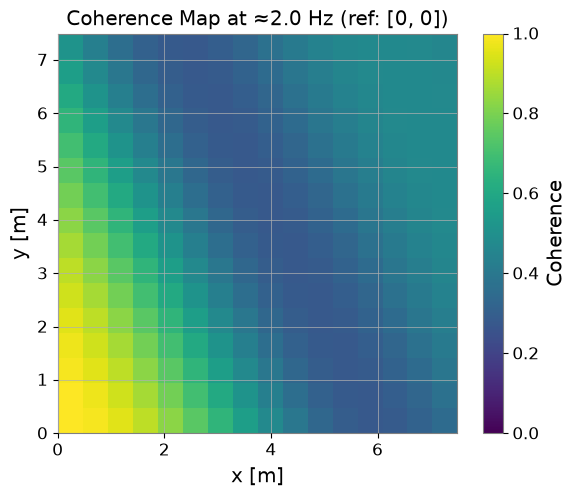

Mean coherence at ≈2.0 Hz: 0.472


In [7]:
# Coherence map at a target frequency relative to reference sensor
from scipy.signal import coherence as _coherence

fs_wave = 1.0 / dt_val  # sample rate

# Compute coherence at each spatial point vs. reference
ref_ts_c = wave_arr[:, 0, 0, 0]
target_hz = 2.0
coh_slice  = np.zeros((len(x_w), len(y_w)))

for ix in range(len(x_w)):
    for iy in range(len(y_w)):
        sig = wave_arr[:, ix, iy, 0]
        f_coh, Cxy = _coherence(ref_ts_c, sig, fs=fs_wave, nperseg=min(64, len(sig)//2))
        bin_idx    = np.argmin(np.abs(f_coh - target_hz))
        coh_slice[ix, iy] = np.abs(Cxy[bin_idx])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(coh_slice.T, origin="lower", vmin=0, vmax=1,
               extent=[x_w[0], x_w[-1], y_w[0], y_w[-1]], cmap="viridis")
ax.set_title(f"Coherence Map at ≈{target_hz:.1f} Hz (ref: [0, 0])")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.colorbar(im, ax=ax, label="Coherence")
plt.tight_layout(); plt.show()
print(f"Mean coherence at ≈{target_hz:.1f} Hz: {coh_slice.mean():.3f}")

## 6. VectorField: Gradient and Norm

For physical fields with vector character (e.g. magnetic field, velocity),
`VectorField` stores multiple `ScalarField` components.  Here we compute
the beam intensity gradient — useful for wavefront sensing.


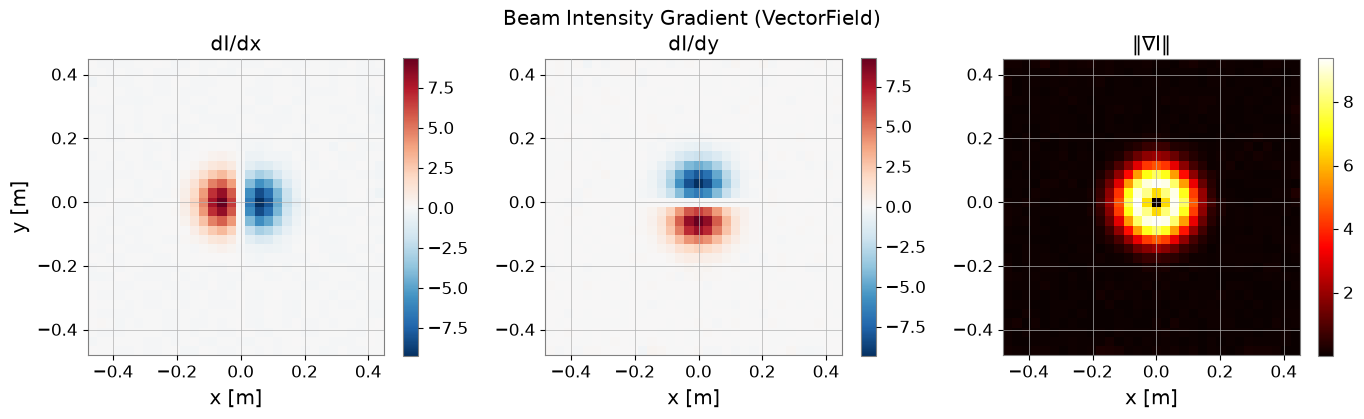

VectorField components: ['x', 'y']
Gradient norm max: 9.393 W/m³


In [8]:
# Intensity gradient: dI/dx and dI/dy from the mean beam profile
grad_x = np.gradient(mean_profile, dx.value, axis=0)   # (nx, ny)
grad_y = np.gradient(mean_profile, dy.value, axis=1)

def make_static_sf(arr2d, x_ax, y_ax, unit):
    d = arr2d[np.newaxis, :, :, np.newaxis]   # (1, nx, ny, 1)
    return ScalarField(d, unit=unit,
                       axis0=np.array([0.0]),
                       axis1=x_ax, axis2=y_ax, axis3=np.array([0.0]),
                       axis_names=["time", "x", "y", "z"])

sf_gx = make_static_sf(grad_x, x, y, u.W / u.m**3)
sf_gy = make_static_sf(grad_y, x, y, u.W / u.m**3)

vf = VectorField(components={"x": sf_gx, "y": sf_gy})
grad_norm = np.asarray(vf.norm().data)[0, :, :, 0]   # (nx, ny)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ["dI/dx", "dI/dy", "‖∇I‖"]
arrays = [grad_x, grad_y, grad_norm]
cmaps  = ["RdBu_r", "RdBu_r", "hot"]
for ax, arr, title, cmap in zip(axes, arrays, titles, cmaps):
    im = ax.imshow(arr.T, origin="lower",
                   extent=[x[0], x[-1], y[0], y[-1]], cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    plt.colorbar(im, ax=ax)

axes[0].set_ylabel("y [m]")
plt.suptitle("Beam Intensity Gradient (VectorField)")
plt.tight_layout()
plt.show()
print("VectorField components:", list(vf.keys()))
print("Gradient norm max:", f"{grad_norm.max():.3f} W/m³")

## Summary

| Analysis | API | Use case |
|----------|-----|----------|
| Mean / variance profile | `sf.data.mean(axis=0)` | Beam centring, stability |
| Temporal PSD | `spectral_density(sf, axis=0)` | Frequency content at each pixel |
| Wavenumber spectrum | `np.fft.rfft` + `ScalarField` | Spatial frequency content |
| Time-delay map | `time_delay_map(sf, ref_indices, axis)` | Propagation velocity |
| Coherence map | `coherence_map(sf, ref_indices, axis, fftlength)` | Correlated oscillations |
| Gradient / norm | `VectorField(components={...}).norm()` | Wavefront sensing |

**Applications at KAGRA / LIGO:**
- Beam profile monitoring and pointing drift correction
- Seismic wavefield characterisation with distributed accelerometer arrays
- Environmental field mapping (magnetic, acoustic) for noise hunting
- Mirror surface deformation from displacement sensor arrays
